# 03 · Segmentação de clientes: RFM + K-Means
[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jessicapmartins/segmentacao-clientes-olist/blob/main/notebooks/03_segmentacao_kmeans.ipynb)

**Pergunta de negócio:** que grupos de clientes existem e que ação de CRM faz sentido para cada um?

**Atenção:** cerca de 97% dos clientes fizeram um único pedido, então a frequência quase não varia. **Decisão:** manter F, mas em escala log (`log1p`). Assim o pequeno grupo que voltou a comprar forma um segmento próprio, que é justamente o grupo mais valioso para o CRM, sem dominar a distância entre os demais clientes.

In [1]:
import sqlite3, pandas as pd

try:                                    # no Colab: lê o banco do seu Google Drive
    from google.colab import drive
    drive.mount('/content/drive')
    DADOS = '/content/drive/MyDrive/03_Portfolio/Projetos_ML/01_segmentacao-clientes-olist/dados'
except ModuleNotFoundError:             # fora do Colab: pasta dados/ do projeto
    DADOS = '../dados'

con = sqlite3.connect(f'{DADOS}/olist.db')

def q(sql):
    """Roda uma consulta SQL no banco da Olist e devolve um DataFrame."""
    return pd.read_sql(sql, con)

import numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
sns.set_theme(style='whitegrid')

In [2]:
# 1) Confere se o banco certo foi aberto (se vier vazio, rode o notebook 00 antes)
tabelas = q("SELECT name FROM sqlite_master WHERE type='table'")['name'].tolist()
print('Banco em uso:', DADOS)
assert 'pedidos' in tabelas, f'O banco em {DADOS} está vazio: rode o notebook 00 antes.'

# 2) Garante que a tabela RFM existe. Ela é criada no notebook 01 (pergunta 10),
#    mas recriamos aqui se faltar, para este notebook rodar sozinho.
con.execute('''
CREATE TABLE IF NOT EXISTS rfm AS
WITH pago AS (SELECT order_id, SUM(payment_value) AS valor_pedido FROM pagamentos GROUP BY order_id),
base AS (
    SELECT c.customer_unique_id, p.order_id,
           date(p.order_purchase_timestamp) AS data_compra, pg.valor_pedido
    FROM clientes c
    JOIN pedidos p ON c.customer_id = p.customer_id
    JOIN pago pg   ON p.order_id   = pg.order_id
    WHERE p.order_status = 'delivered'
),
referencia AS (SELECT MAX(data_compra) AS ultima_data_base FROM base)
SELECT b.customer_unique_id,
       CAST(julianday(r.ultima_data_base) - julianday(MAX(b.data_compra)) AS INT) AS recencia,
       COUNT(DISTINCT b.order_id)    AS frequencia,
       ROUND(SUM(b.valor_pedido), 2) AS valor
FROM base b CROSS JOIN referencia r
GROUP BY b.customer_unique_id
''')
con.commit()

rfm = q('SELECT * FROM rfm')
rfm.describe().round(2)


Banco em uso: ../dados


,recencia,frequencia,valor
count,93357.00,93357.00,93357.00
mean,237.47,1.03,165.20
std,152.59,0.21,226.31
min,0.00,1.00,9.59
25%,114.00,1.00,63.06
50%,218.00,1.00,107.78
75%,346.00,1.00,182.56
max,695.00,15.00,13664.08


## 1. Preparar
Valor e frequência são muito assimétricos: aplicamos `np.log1p` (log de 1 + x). Depois padronizamos as três variáveis com `StandardScaler` para que todas pesem igual na distância do K-Means (ver pôster 05).

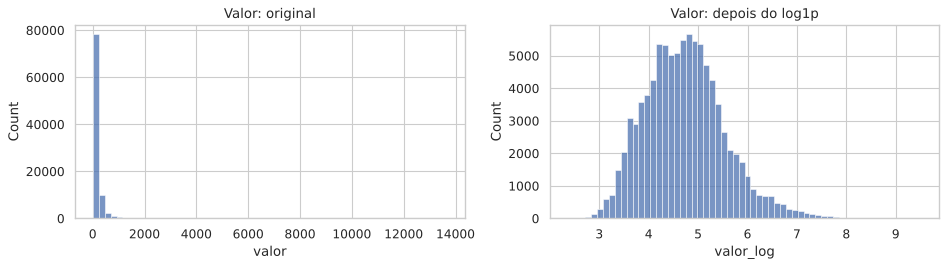

In [3]:
X = pd.DataFrame({
    'recencia':       rfm['recencia'],
    'frequencia_log': np.log1p(rfm['frequencia']),
    'valor_log':      np.log1p(rfm['valor']),
})
Xs = StandardScaler().fit_transform(X)        # média 0 e desvio 1 em cada coluna

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
sns.histplot(rfm['valor'], bins=60, ax=ax[0]); ax[0].set_title('Valor: original')
sns.histplot(X['valor_log'], bins=60, ax=ax[1]); ax[1].set_title('Valor: depois do log1p')
plt.tight_layout(); plt.show()

**O que aprendi:** o valor vai de R$ 9,59 a R$ 13.664,08, com mediana de R$ 107,78: sem o log, poucos clientes muito caros dominariam a distância do K-Means. Depois do log1p, a distribuição fica próxima de um sino.

## 2. Quantos grupos?
K de 2 a 10, comparando **inércia** (cotovelo: quanto menor, mais compactos os grupos) e **silhouette** (de -1 a 1: quanto maior, mais bem separados). O silhouette usa uma amostra de 20 mil clientes porque é pesado.

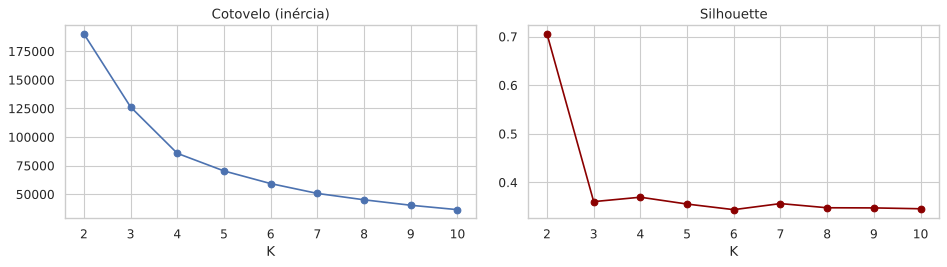

,k,inercia,silhouette
0,2,190194.285,0.706
1,3,126269.807,0.360
2,4,85768.061,0.370
3,5,70371.939,0.355
4,6,59316.617,0.344
5,7,50721.639,0.356
6,8,45145.156,0.348
7,9,40376.075,0.348
8,10,36525.949,0.346


In [4]:
amostra = np.random.RandomState(42).choice(len(Xs), 20_000, replace=False)

resultados = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xs)
    resultados.append({'k': k, 'inercia': km.inertia_,
                       'silhouette': silhouette_score(Xs[amostra], km.labels_[amostra])})
resultados = pd.DataFrame(resultados)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].plot(resultados['k'], resultados['inercia'], marker='o'); ax[0].set_title('Cotovelo (inércia)')
ax[1].plot(resultados['k'], resultados['silhouette'], marker='o', color='darkred'); ax[1].set_title('Silhouette')
for a in ax: a.set_xlabel('K')
plt.tight_layout(); plt.show()
resultados.round(3)

**O que aprendi:** K = 2 tem o maior silhouette (0,706), mas só separa quem comprou mais de uma vez de quem não comprou, uma divisão óbvia que não ajuda o CRM. Entre K ≥ 3, K = 4 tem o maior silhouette (0,370) e fica no 'cotovelo' da inércia, onde o ganho de compactação começa a diminuir. Escolhi K = 4.

## 3. Treinar o K-Means e descrever os grupos
Os grupos recebem nomes de negócio por regra (e não pelo número do cluster, que pode mudar entre execuções):
o grupo com maior frequência é **Recorrentes**; entre os demais, o de maior recência é **Inativos**; dos dois que sobram, o de maior valor é **Alto valor** e o outro, **Novos de baixo valor**.

In [5]:
K = 4
km = KMeans(n_clusters=K, n_init=10, random_state=42).fit(Xs)
rfm['cluster'] = km.labels_

perfil = rfm.groupby('cluster').agg(clientes=('customer_unique_id', 'count'),
                                    recencia=('recencia', 'mean'),
                                    frequencia=('frequencia', 'mean'),
                                    valor=('valor', 'mean'))

# Nomes de negócio por regra
nomes = {}
recorr = perfil['frequencia'].idxmax();                         nomes[recorr] = 'Recorrentes'
resto = perfil.drop(recorr)
inativo = resto['recencia'].idxmax();                            nomes[inativo] = 'Inativos'
resto = resto.drop(inativo)
nomes[resto['valor'].idxmax()] = 'Alto valor'
nomes[resto['valor'].idxmin()] = 'Novos de baixo valor'
rfm['segmento'] = rfm['cluster'].map(nomes)

resumo = (rfm.groupby('segmento')
             .agg(clientes=('customer_unique_id', 'count'),
                  recencia_media=('recencia', 'mean'),
                  frequencia_media=('frequencia', 'mean'),
                  valor_medio=('valor', 'mean'),
                  valor_total=('valor', 'sum')))
resumo['pct_clientes'] = 100 * resumo['clientes'] / resumo['clientes'].sum()
resumo['pct_receita']  = 100 * resumo['valor_total'] / resumo['valor_total'].sum()
resumo.drop(columns='valor_total').sort_values('valor_medio', ascending=False).round(1)

,clientes,recencia_media,frequencia_media,valor_medio,pct_clientes,pct_receita
segmento,,,,,,
Alto valor,27832,172.9,1.0,318.4,29.8,57.5
Recorrentes,2801,219.8,2.1,308.6,3.0,5.6
Inativos,27047,424.7,1.0,119.6,29.0,21.0
Novos de baixo valor,35677,147.3,1.0,69.1,38.2,16.0


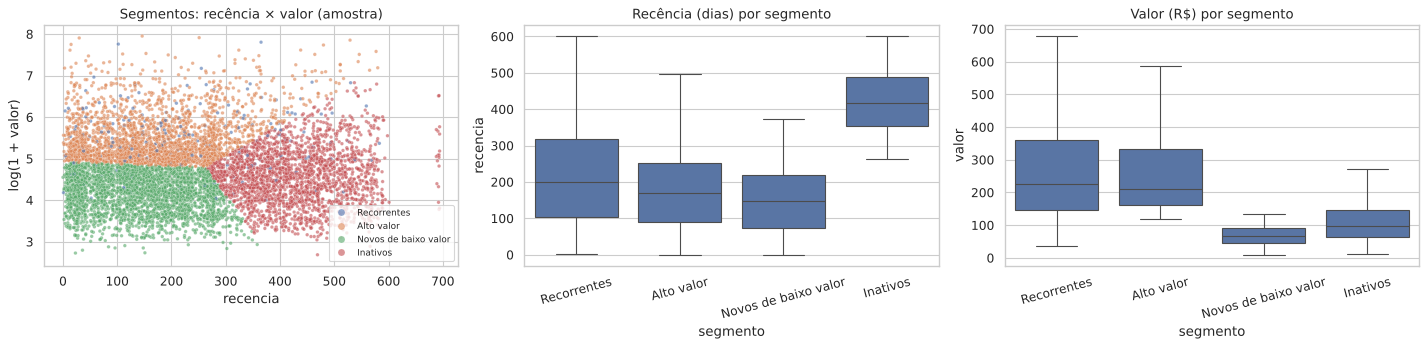

In [6]:
ordem = ['Recorrentes', 'Alto valor', 'Novos de baixo valor', 'Inativos']
fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))

amostra_plot = rfm.sample(8_000, random_state=42)
sns.scatterplot(data=amostra_plot, x='recencia', y=np.log1p(amostra_plot['valor']), hue='segmento',
                hue_order=ordem, s=10, alpha=0.6, ax=ax[0])
ax[0].legend(loc='lower right', fontsize=8, markerscale=2); ax[0].set_ylabel('log(1 + valor)'); ax[0].set_title('Segmentos: recência × valor (amostra)')

sns.boxplot(data=rfm, x='segmento', y='recencia', order=ordem, ax=ax[1], showfliers=False)
ax[1].set_title('Recência (dias) por segmento'); ax[1].tick_params(axis='x', rotation=15)

sns.boxplot(data=rfm, x='segmento', y='valor', order=ordem, ax=ax[2], showfliers=False)
ax[2].set_title('Valor (R$) por segmento'); ax[2].tick_params(axis='x', rotation=15)

plt.tight_layout(); plt.show()

**O que aprendi:** os quatro segmentos têm perfis bem distintos. **Alto valor** (29,8% dos clientes) gera 57,5% da receita, com valor médio de R$ 318. **Novos de baixo valor** é o maior grupo (38,2%), comprou há pouco tempo (147 dias em média), mas gasta R$ 69 em média. **Inativos** (29,0%) não compram há 425 dias em média. **Recorrentes** são só 3,0% dos clientes, com 2,1 pedidos e R$ 309 em média.

## 4. Comparar com clusterização hierárquica
`AgglomerativeClustering` (método Ward) numa amostra de 5 mil clientes, com o mesmo K. O **Adjusted Rand Index** (ARI) mede a concordância entre as duas divisões: 1 = idênticas, 0 = concordância de acaso.

In [7]:
amostra_h = np.random.RandomState(7).choice(len(Xs), 5_000, replace=False)
hier = AgglomerativeClustering(n_clusters=K, linkage='ward').fit_predict(Xs[amostra_h])

print('ARI K-Means × hierárquica:', round(adjusted_rand_score(km.labels_[amostra_h], hier), 3))
pd.crosstab(rfm['segmento'].values[amostra_h], hier, rownames=['K-Means'], colnames=['Hierárquica'])

ARI K-Means × hierárquica: 0.543


Hierárquica,0,1,2,3
K-Means,,,,
Alto valor,359,5,1127,0
Inativos,1483,0,0,0
Novos de baixo valor,385,1376,113,0
Recorrentes,0,0,0,152


**O que aprendi:** o ARI de 0,543 indica concordância moderada. Os dois métodos isolam exatamente o mesmo grupo de Recorrentes e colocam todos os Inativos juntos; a diferença está na fronteira entre Alto valor e Novos de baixo valor, que a hierárquica divide de outro jeito. A fronteira por valor é contínua, não um corte natural, então os segmentos devem ser lidos como faixas de prioridade, não como grupos rígidos.

## 5. Ações por segmento
| Segmento | Tamanho | Perfil | Ação de CRM sugerida |
|---|---|---|---|
| **Recorrentes** | 2.801 (3,0%) | 2,1 pedidos, R$ 309 em média | Programa de fidelidade, acesso antecipado a promoções, recomendações por histórico |
| **Alto valor** | 27.832 (29,8%) | 57,5% da receita, compra única de R$ 318 em média | Prioridade nº 1 para a 2ª compra: cupom na categoria comprada, frete grátis acima de um valor mínimo, pós-venda caprichado |
| **Novos de baixo valor** | 35.677 (38,2%) | Compra recente, R$ 69 em média | Aumentar o ticket: kits, frete grátis por valor mínimo, recomendações de produtos complementares |
| **Inativos** | 27.047 (29,0%) | Sem comprar há 425 dias em média | Reativação de baixo custo (e-mail, push); testar antes de investir, porque a chance de retorno é menor |

In [8]:
# Salva o segmento de cada cliente para o dashboard (notebook 06) e para as personas (notebook 05)
rfm[['customer_unique_id', 'recencia', 'frequencia', 'valor', 'segmento']].to_sql(
    'segmentos', con, if_exists='replace', index=False)
q('SELECT segmento, COUNT(*) AS clientes FROM segmentos GROUP BY segmento')

,segmento,clientes
0,Alto valor,27832
1,Inativos,27047
2,Novos de baixo valor,35677
3,Recorrentes,2801


## Conclusão
A segmentação transformou 93.357 clientes em quatro grupos acionáveis. O achado principal é que **30% dos clientes (Alto valor) concentram 57,5% da receita, mas quase todos compraram uma única vez**. Converter parte deles em Recorrentes é a maior alavanca de receita. Os próximos notebooks testam a mesma segmentação com deep learning (autoencoder) e usam IA generativa para escrever uma persona e uma mensagem de CRM para cada segmento.

## Gravar no Google Drive
Fecha o banco e força o Drive a gravar as mudanças agora. Sem isso, o próximo notebook, que roda em outra sessão do Colab, pode não enxergar as tabelas novas.

In [9]:
con.commit()
con.close()
try:
    drive.flush_and_unmount()      # só existe no Colab
    print('Banco gravado no Google Drive.')
except NameError:
    print('Fora do Colab: nada a sincronizar.')

Fora do Colab: nada a sincronizar.
